# Manual Labeling: Working with Pre-Labeled Datasets

Learn how to work with datasets that already have labels and prepare them for MPLAB ML:
- Load pre-labeled sensor data
- Understand label transitions
- Create segments from continuous labels
- Build .dclproj manifest files
- Upload to MPLAB ML

**Use Case:** You have sensor data with existing labels (from research datasets, previous projects, or manual annotation) and want to use it in MPLAB ML.

**Dataset:** IEEE Arc Fault Detection Dataset (series_load sample)
- 200,000 samples (~12.5 seconds)
- 16 kHz sampling rate
- Labels: -1 (normal), 0 (transient), 1 (arc fault)

---
## 1. Setup

In [1]:
!pip install mplabml --quiet
print("✓ MPLAB ML SDK installed")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.8/180.8 kB 5.7 MB/s eta 0:00:00
✓ MPLAB ML SDK installed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from getpass import getpass
from mplabml import Client

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)

print("✓ Libraries imported")

✓ Libraries imported


---
## 2. Quick Data Quality Recap

💡 **Remember from understanding-data.ipynb:**
- Data should be in sequential format (one reading per row)
- Check for missing values, outliers, label consistency
- Visualize to understand patterns

This dataset is **already cleaned** - it passed all quality checks:
- ✅ Sequential format
- ✅ No missing values
- ✅ No outliers
- ✅ Consistent labels

Now we'll focus on **converting these labels into a format MPLAB ML understands**.

---
## 3. Load Pre-Labeled Dataset

**Two options to load the sample data:**

### Option 1: Load Directly from GitHub (Easiest)
Works in both Colab and local Jupyter - no download needed!

### Option 2: Use Local File
- **Colab:** Upload file to `/content/` folder
- **Local Jupyter:** Clone the repo or specify your local path

Choose the option that works best for you:

### Option 1: Load from GitHub (Recommended)

In [ ]:
# Load directly from GitHub - works everywhere!
GITHUB_URL = 'https://raw.githubusercontent.com/MicrochipTech/mplabml-sdk-examples/main/datasets/series_load_sample.csv'

print(f"Loading from GitHub...")
df = pd.read_csv(GITHUB_URL)

print(f"\n✓ Loaded {len(df):,} samples")
print(f"  Duration: {df['Time'].max():.2f} seconds")
print(f"  Sampling rate: ~{1/(df['Time'].iloc[1] - df['Time'].iloc[0]):.0f} Hz")
print(f"  Columns: {list(df.columns)}")

### Option 2: Load from Local File

**Skip this section if you used Option 1 above.**

#### For Google Colab:
1. Download `series_load_sample.csv` from the [GitHub repo](https://github.com/MicrochipTech/mplabml-sdk-examples/tree/main/datasets/arc-fault/series-load)
2. Upload to Colab using the file browser (left sidebar)
3. File will be in `/content/series_load_sample.csv`

#### For Local Jupyter:
Either:
- Clone the repo: `git clone https://github.com/MicrochipTech/mplabml-sdk-examples.git`
- Or download the CSV and specify your path below

In [3]:
# Uncomment and run ONLY if you want to use a local file instead of GitHub

# # For Colab (after uploading file)
# LOCAL_PATH = '/content/series_load_sample.csv'

# # For Local Jupyter (if you cloned the repo)
# LOCAL_PATH = '../datasets/arc-fault/series-load/series_load_sample.csv'

# # For Local Jupyter (custom path)
# LOCAL_PATH = '/path/to/your/series_load_sample.csv'

# print(f"Loading from: {LOCAL_PATH}...")
# df = pd.read_csv(LOCAL_PATH)

# print(f"\n✓ Loaded {len(df):,} samples")
# print(f"  Duration: {df['Time'].max():.2f} seconds")
# print(f"  Sampling rate: ~{1/(df['Time'].iloc[1] - df['Time'].iloc[0]):.0f} Hz")
# print(f"  Columns: {list(df.columns)}")

Loading from: /content/series_load_sample.csv...

✓ Loaded 200,000 samples
  Duration: 12.50 seconds
  Sampling rate: ~16000 Hz
  Columns: ['Time', 'current_signal', 'label']


In [6]:
# Inspect the data
print("First 10 rows:")
display(df.head(10))

print("\nDataset info:")
df.info()

First 10 rows:


,Time,current_signal,label
0,0.000000,4.360971,-1.0
1,0.000063,4.361415,-1.0
2,0.000125,4.361229,-1.0
3,0.000188,4.361372,-1.0
4,0.000250,4.360886,-1.0
5,0.000313,4.361994,-1.0
6,0.000375,4.361637,-1.0
7,0.000438,4.360514,-1.0
8,0.000500,4.361336,-1.0
9,0.000562,4.361336,-1.0



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Time            200000 non-null  float64
 1   current_signal  200000 non-null  float64
 2   label           200000 non-null  float64
dtypes: float64(3)
memory usage: 4.6 MB


In [7]:
# Label distribution
print("Label distribution:")
label_counts = df['label'].value_counts().sort_index()

label_names = {-1.0: 'Normal', 0.0: 'Transient', 1.0: 'Arc Fault'}
for label, count in label_counts.items():
    pct = (count / len(df)) * 100
    name = label_names.get(label, 'Unknown')
    print(f"  {int(label):2d} ({name:>10s}): {count:>7,} samples ({pct:>5.1f}%)")

print(f"\nTotal: {len(df):,} samples")

Label distribution:
  -1 (    Normal):  21,760 samples ( 10.9%)
   0 ( Transient):   2,560 samples (  1.3%)
   1 ( Arc Fault): 175,680 samples ( 87.8%)

Total: 200,000 samples


---
## 4. Visualize Labels Over Time

Understanding how labels change over time is crucial for creating segments.

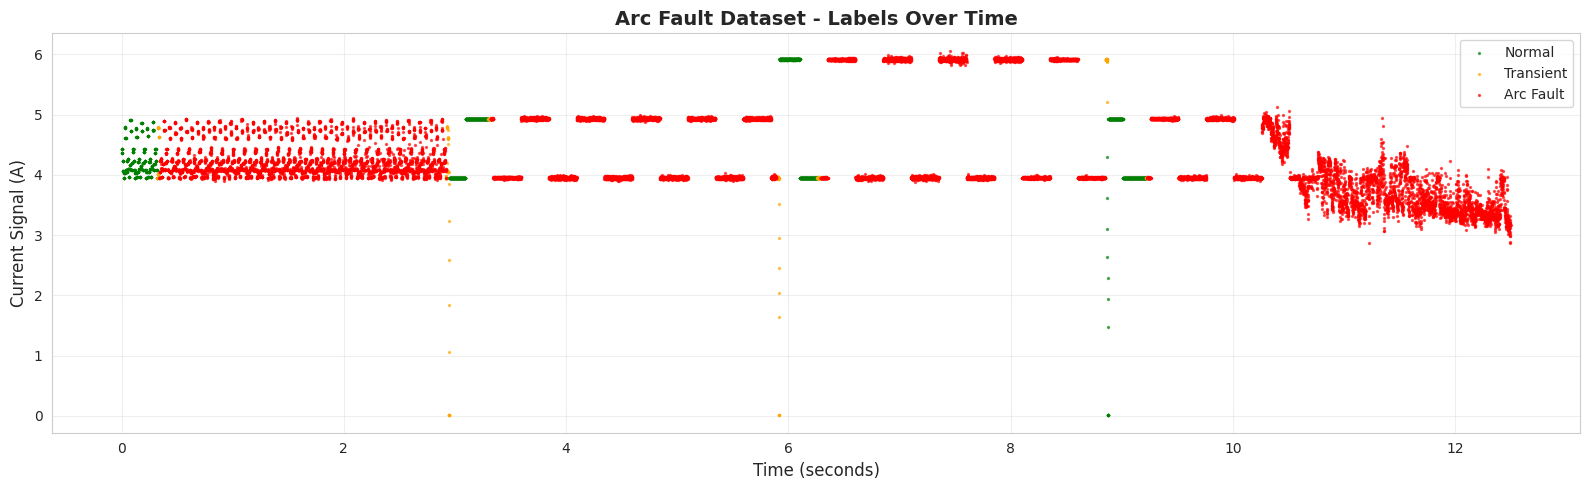

💡 Notice how labels change as the signal characteristics change
   These transition points will become 'segments' for MPLAB ML


In [8]:
# Plot signal with labels
plt.figure(figsize=(16, 5))

# Color map for labels
colors = {-1.0: 'green', 0.0: 'orange', 1.0: 'red'}
labels_map = {-1.0: 'Normal', 0.0: 'Transient', 1.0: 'Arc Fault'}

# Plot every 10th point for performance
plot_data = df[::10].copy()

for label_val in sorted(df['label'].unique()):
    mask = plot_data['label'] == label_val
    plt.scatter(plot_data[mask]['Time'],
                plot_data[mask]['current_signal'],
                c=colors[label_val],
                label=labels_map[label_val],
                alpha=0.6, s=2)

plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Current Signal (A)', fontsize=12)
plt.title('Arc Fault Dataset - Labels Over Time', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Notice how labels change as the signal characteristics change")
print("   These transition points will become 'segments' for MPLAB ML")

---
## 5. Understanding Segments

**What is a segment?**
A segment is a continuous section of data with the **same label**.

**Example:**
```
Samples 0-1000:     label = normal    → Segment 1
Samples 1001-1500:  label = transient → Segment 2  
Samples 1501-2000:  label = arc_fault → Segment 3
```

**Why segments?**
MPLAB ML needs to know where each label starts and ends to properly train models.

---
## 6. Create Segments from Labels

Let's convert our continuous label column into discrete segments.

In [9]:
def create_segments_from_labels(df, label_col='label'):
    """
    Create segments by detecting where labels change.

    Parameters:
    -----------
    df : DataFrame
        DataFrame with continuous label column
    label_col : str
        Name of the label column

    Returns:
    --------
    list : Segments in MPLAB ML format
    """
    # Map numeric labels to string names
    label_map = {
        -1.0: 'normal',
        0.0: 'transient',
        1.0: 'arc_observed'
    }

    segments = []
    current_label = df[label_col].iloc[0]
    start_idx = 0

    # Scan through data to find label changes
    for i in range(1, len(df)):
        if df[label_col].iloc[i] != current_label:
            # Label changed - save previous segment
            segments.append({
                "name": "Label",
                "value": label_map[current_label],
                "start": int(start_idx),
                "end": int(i - 1)
            })

            # Start new segment
            current_label = df[label_col].iloc[i]
            start_idx = i

    # Add final segment
    segments.append({
        "name": "Label",
        "value": label_map[current_label],
        "start": int(start_idx),
        "end": int(len(df) - 1)
    })

    return segments

# Create segments
segments = create_segments_from_labels(df)

print(f"✓ Created {len(segments)} segments\n")
print("Segments:")
for i, seg in enumerate(segments, 1):
    duration = seg['end'] - seg['start'] + 1
    time_start = df['Time'].iloc[seg['start']]
    time_end = df['Time'].iloc[seg['end']]
    print(f"  {i}. {seg['value']:<13s}: samples {seg['start']:>6,} to {seg['end']:>6,} "
          f"({duration:>6,} samples, {time_start:.3f}s to {time_end:.3f}s)")

✓ Created 15 segments

Segments:
  1. normal       : samples      0 to  5,119 ( 5,120 samples, 0.000s to 0.320s)
  2. transient    : samples  5,120 to  5,439 (   320 samples, 0.320s to 0.340s)
  3. arc_observed : samples  5,440 to 46,719 (41,280 samples, 0.340s to 2.920s)
  4. transient    : samples 46,720 to 47,199 (   480 samples, 2.920s to 2.950s)
  5. normal       : samples 47,200 to 52,799 ( 5,600 samples, 2.950s to 3.300s)
  6. transient    : samples 52,800 to 53,119 (   320 samples, 3.300s to 3.320s)
  7. arc_observed : samples 53,120 to 94,239 (41,120 samples, 3.320s to 5.890s)
  8. transient    : samples 94,240 to 94,719 (   480 samples, 5.890s to 5.920s)
  9. normal       : samples 94,720 to 100,159 ( 5,440 samples, 5.920s to 6.260s)
  10. transient    : samples 100,160 to 100,639 (   480 samples, 6.260s to 6.290s)
  11. arc_observed : samples 100,640 to 141,599 (40,960 samples, 6.290s to 8.850s)
  12. transient    : samples 141,600 to 141,919 (   320 samples, 8.850s to 8.870

### Verify Segments

Let's check that our segments match the actual data:

In [10]:
# Verify each segment
print("Segment verification:")
label_map = {-1.0: 'normal', 0.0: 'transient', 1.0: 'arc_observed'}

for i, seg in enumerate(segments, 1):
    # Get actual labels in this range
    actual_labels = df['label'].iloc[seg['start']:seg['end']+1].unique()
    actual_names = [label_map[l] for l in actual_labels]

    # Check if segment has only one label
    if len(actual_labels) == 1 and actual_names[0] == seg['value']:
        print(f"  ✓ Segment {i}: {seg['value']} - Correct!")
    else:
        print(f"  ❌ Segment {i}: Expected {seg['value']}, found {actual_names}")

print("\n✓ All segments verified!")

Segment verification:
  ✓ Segment 1: normal - Correct!
  ✓ Segment 2: transient - Correct!
  ✓ Segment 3: arc_observed - Correct!
  ✓ Segment 4: transient - Correct!
  ✓ Segment 5: normal - Correct!
  ✓ Segment 6: transient - Correct!
  ✓ Segment 7: arc_observed - Correct!
  ✓ Segment 8: transient - Correct!
  ✓ Segment 9: normal - Correct!
  ✓ Segment 10: transient - Correct!
  ✓ Segment 11: arc_observed - Correct!
  ✓ Segment 12: transient - Correct!
  ✓ Segment 13: normal - Correct!
  ✓ Segment 14: transient - Correct!
  ✓ Segment 15: arc_observed - Correct!

✓ All segments verified!


---
## 7. Prepare Data for Upload

MPLAB ML needs:
1. CSV file with the sensor data
2. .dclproj manifest that links the CSV to segments

In [17]:
# Create output directory
OUTPUT_DIR = 'manual_labeling_tutorial'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"✓ Created output directory: {OUTPUT_DIR}")

✓ Created output directory: manual_labeling_tutorial


In [18]:
# Save CSV (without the label column - MPLAB ML will use segments instead)
csv_filename = 'sensor_data.csv'
csv_path = os.path.join(OUTPUT_DIR, csv_filename)

# Save only Time and current_signal columns
df[['Time', 'current_signal']].to_csv(csv_path, index=False)

print(f"✓ Saved CSV: {csv_path}")
print(f"  Size: {os.path.getsize(csv_path) / (1024*1024):.1f} MB")

✓ Saved CSV: manual_labeling_tutorial/sensor_data.csv
  Size: 5.5 MB


---
## 8. Build .dclproj Manifest

The manifest is a JSON file that tells MPLAB ML:
- Which CSV file contains the data
- Metadata about the dataset
- Where each label segment starts and ends

In [19]:
# Create manifest structure
manifest = [{
    "file_name": csv_filename,
    "metadata": [
        {"name": "example_type", "value": "manual_labeling_tutorial"},
        {"name": "use_case", "value": "arc_fault_detection"},
        {"name": "source", "value": "IEEE_series_load_sample"},
        {"name": "sampling_rate_hz", "value": "16000"},
        {"name": "description", "value": "tutorial_example_with_prelabeled_data"}
    ],
    "sessions": [{
        "session_name": "Session_1",
        "segments": segments
    }]
}]

# Save manifest (.dclproj file)
manifest_filename = 'manual_labeling_tutorial.dclproj'
manifest_path = os.path.join(OUTPUT_DIR, manifest_filename)
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"✓ Saved manifest: {manifest_path}")
print(f"\nManifest preview (first 500 chars):")
print(json.dumps(manifest, indent=2)[:500] + "...")

✓ Saved manifest: manual_labeling_tutorial/manual_labeling_tutorial.dclproj

Manifest preview (first 500 chars):
[
  {
    "file_name": "sensor_data.csv",
    "metadata": [
      {
        "name": "example_type",
        "value": "manual_labeling_tutorial"
      },
      {
        "name": "use_case",
        "value": "arc_fault_detection"
      },
      {
        "name": "source",
        "value": "IEEE_series_load_sample"
      },
      {
        "name": "sampling_rate_hz",
        "value": "16000"
      },
      {
        "name": "description",
        "value": "tutorial_example_with_prelabeled_data"
   ...


### Understanding the Manifest Structure

**Important:** Metadata values can only contain **letters, numbers, and underscores**.
- ✅ Good: `tutorial_example`, `arc_fault_detection`, `16000`
- ❌ Bad: `Tutorial: Example`, `arc-fault (detection)`, `16,000`

```json
[
  {
    "file_name": "sensor_data.csv",            // Which CSV file
    "metadata": [                              // Dataset information
      {"name": "example_type", "value": "manual_labeling_tutorial"},
      {"name": "use_case", "value": "arc_fault_detection"},
      {"name": "description", "value": "tutorial_example_with_prelabeled_data"},
      ...
    ],
    "sessions": [                              // Can have multiple sessions
      {
        "session_name": "Session_1",
        "segments": [                          // Label definitions
          {
            "name": "Label",
            "value": "normal",                 // Label name (also letters/numbers/underscores only)
            "start": 0,                        // Start sample index
            "end": 50000                       // End sample index
          },
          ...
        ]
      }
    ]
  }
]
```

---
## 9. Verify Project Structure

Before uploading, verify everything is in place:

**Required files:**
1. `sensor_data.csv` - Your sensor data
2. `manual_labeling_tutorial.dclproj` - Manifest with label segments

In [20]:
print("Project structure:")
print(f"\n{OUTPUT_DIR}/")

for item in os.listdir(OUTPUT_DIR):
    path = os.path.join(OUTPUT_DIR, item)
    if os.path.isfile(path):
        size = os.path.getsize(path) / 1024
        print(f"  ├── {item:<30s} ({size:>8.1f} KB)")

print("\n✓ Project ready for upload!")

Project structure:

manual_labeling_tutorial/
  ├── sensor_data.csv                (  5598.1 KB)
  ├── manual_labeling_tutorial.dclproj (     2.7 KB)

✓ Project ready for upload!


---
## 10. Upload to MPLAB ML

Now we'll upload the project to MPLAB ML. The SDK will:
1. Upload the CSV file
2. Parse the manifest
3. Apply all segments/labels automatically

In [21]:
# Authenticate
api_key = getpass("Enter your MPLAB ML API Key: ")
client = Client(api_key=api_key)

print("✓ Connected to MPLAB ML!")

Enter your MPLAB ML API Key: ··········
Client connected to the cloud successfully
✓ Connected to MPLAB ML!


In [22]:
# Upload project
PROJECT_NAME = "Manual_Labeling_Tutorial"

print("=" * 70)
print(f"UPLOADING PROJECT: {PROJECT_NAME}")
print("=" * 70)
print(f"\nManifest: {manifest_filename}")
print(f"Upload directory: {OUTPUT_DIR}")
print(f"\n⏳ Upload in progress...")
print("   This may take 30-60 seconds...\n")

try:
    # Upload project with manifest
    result = client.upload_project_dcli(
        name=PROJECT_NAME,
        dcli_path=manifest_path,
        force=True  # Overwrite if project already exists
    )

    print("\n" + "=" * 70)
    print("✅ UPLOAD COMPLETED SUCCESSFULLY!")
    print("=" * 70)
    print(f"\nProject '{PROJECT_NAME}' is now in MPLAB ML!\n")
    print("💡 This is a tutorial example using arc fault data.")
    print("   You can safely delete it after exploring the labeling workflow.\n")

except Exception as e:
    print("\n" + "=" * 70)
    print("❌ UPLOAD FAILED")
    print("=" * 70)
    print(f"\nError: {e}\n")
    print("Troubleshooting:")
    print("1. Check your internet connection")
    print("2. Verify MPLAB ML credentials (API key)")
    print("3. Ensure manifest and CSV files are in same directory")
    print(f"4. Check files exist in: {OUTPUT_DIR}")
    print("5. Try re-running the upload cell\n")
    raise

UPLOADING PROJECT: Manual_Labeling_Tutorial

Manifest: manual_labeling_tutorial.dclproj
Upload directory: manual_labeling_tutorial

⏳ Upload in progress...
   This may take 30-60 seconds...

Project Manual_Labeling_Tutorial does not exist, creating a new project.
Uploading Capture 0/1: sensor_data.csv
Segmenter Uploaded.

✅ UPLOAD COMPLETED SUCCESSFULLY!

Project 'Manual_Labeling_Tutorial' is now in MPLAB ML!

💡 This is a tutorial example using arc fault data.
   You can safely delete it after exploring the labeling workflow.



---
## 11. Verify Upload

In [23]:
# List projects to verify
projects_df = client.list_projects()

if PROJECT_NAME in projects_df['Name'].values:
    print(f"✅ Found project: {PROJECT_NAME}\n")
    project_info = projects_df[projects_df['Name'] == PROJECT_NAME]
    display(project_info[['Name', 'Last Modified', 'Created']])
else:
    print(f"❌ Project not found: {PROJECT_NAME}")

print("\n💡 Next steps:")
print("   1. Go to https://mplabml.microchip.com")
print(f"   2. Open project: {PROJECT_NAME}")
print("   3. View your data with labels already applied!")
print("   4. Create a query to select your training data")
print("   5. Build a pipeline and train a model")

✅ Found project: Manual_Labeling_Tutorial



,Name,Last Modified,Created
5,Manual_Labeling_Tutorial,2025-12-17 17:29:19.300,2025-12-17 17:29:19.300



💡 Next steps:
   1. Go to https://mplabml.microchip.com
   2. Open project: Manual_Labeling_Tutorial
   3. View your data with labels already applied!
   4. Create a query to select your training data
   5. Build a pipeline and train a model


---
## Summary

### What We Accomplished:

1. ✅ **Loaded pre-labeled data** - 200k samples with existing labels
2. ✅ **Understood segments** - Continuous sections with same label
3. ✅ **Created segments** - Detected label transitions automatically
4. ✅ **Built manifest** - .dclproj file linking CSV to segments
5. ✅ **Uploaded to MPLAB ML** - Complete project with labels

### Key Concepts:

**Segment:**
```json
{
  "name": "Label",
  "value": "normal",
  "start": 0,
  "end": 50000
}
```
Tells MPLAB ML: "Samples 0-50000 are labeled 'normal'"

**Note:** Label values must use only letters, numbers, and underscores.

**Manifest (.dclproj):**
- JSON file describing dataset structure
- Links CSV file to label segments
- Required for uploading pre-labeled data

**Upload Process:**
1. CSV + .dclproj in same folder
2. `client.upload_project_dcli(name, dcli_path, force=True)`
3. Labels automatically applied in MPLAB ML

### Workflow for Your Own Data:

```python
# 1. Load your labeled data
df = pd.read_csv('my_data.csv')

# 2. Create segments from labels
segments = create_segments_from_labels(df, label_col='my_label_column')

# 3. Save CSV (without label column)
df.drop('my_label_column', axis=1).to_csv('sensor_data.csv', index=False)

# 4. Build manifest (.dclproj)
manifest = [{
    "file_name": "sensor_data.csv",
    "metadata": [
        {"name": "description", "value": "your_dataset_description"},
        {"name": "use_case", "value": "your_application"},
        {"name": "sampling_rate_hz", "value": "1000"}
        # NOTE: Values can only contain letters, numbers, and underscores!
    ],
    "sessions": [{"session_name": "Session_1", "segments": segments}]
}]

# 5. Save manifest
with open('my_project.dclproj', 'w') as f:
    json.dump(manifest, f, indent=2)

# 6. Upload
client.upload_project_dcli(
    name="My_ML_Project",
    dcli_path="my_project.dclproj",
    force=True
)
```

---

## Next Steps

**Continue Learning:**
- [Threshold Labeling](./threshold-labeling.ipynb) - Auto-label by signal characteristics (coming soon)
- [Event-Triggered Labeling](./event-triggered-labeling.ipynb) - Label based on events (coming soon)

**In MPLAB ML:**
1. Create a query to select training data
2. Build feature extraction pipeline
3. Train and evaluate models
4. Generate Knowledge Pack for deployment

---

**🎉 Congratulations!** You've successfully uploaded pre-labeled data to MPLAB ML!